In [4]:
cd /Users/safishajjouz/GitHub/myPythonPackages

/Users/safishajjouz/GitHub/myPythonPackages


In [5]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myReturns import *
from myPortfolioManagement.myPlots import *
from myPortfolioManagement.myClustering import *
from myPortfolioManagement.myBacktesting import *

/Users/safishajjouz/opt/anaconda3/envs/myport_management_env/lib/python3.8/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [6]:
port = get_multi_asset_returns()
bench = download_returns(['^IXIC'])
bench2 = download_returns(['^GSPC'])
stock = download_returns(['BRK-A'])
#stock = stock[stock.index>='2005']

In [11]:
stock_price = get_stock_prices(['BRK-A'])

get_stock_prices took 7.298sec


In [20]:
stock_price[stock_price['adjclose'].max()==stock_price['adjclose']]

,high,low,open,close,volume,adjclose,yahoo_ticker,instrumentType,isin,quoteType,stock,symbol,current_market_cap,beta,sector,industry
Date,,,,,,,,,,,,,,,,
2022-03-28,544000.0,533345.0,540913.0,539180.0,38,539180.0,BRK-A,EQUITY,-,EQUITY,Berkshire Hathaway Inc.,BRK-A,671.5943,0.857843,Financial Services,Insurance—Diversified


In [21]:
(stock_price[['adjclose']].tail(1) - stock_price['adjclose'].max())/stock_price['adjclose'].max()

,adjclose
Date,
2022-05-10,-0.128714


                           Strategy
-------------------------  -----------
Start Period               1980-03-17
End Period                 2022-05-12
Risk-Free Rate             2.0%
Time in Market             87.0%

Cumulative Return          157,585.73%
CAGR﹪                     19.07%

Sharpe                     0.79
Smart Sharpe               0.78
Sortino                    1.21
Smart Sortino              1.19
Sortino/√2                 0.85
Smart Sortino/√2           0.84
Omega                      1.17

Max Drawdown               -51.47%
Longest DD Days            1971
Volatility (ann.)          22.85%
Calmar                     0.37
Skew                       0.43
Kurtosis                   13.18

Expected Daily %           0.07%
Expected Monthly %         1.46%
Expected Yearly %          18.68%
Kelly Criterion            8.25%
Risk of Ruin               0.0%
Daily Value-at-Risk        -2.29%
Expected Shortfall (cVaR)  -2.29%

Gain/Pain Ratio            0.19
Gain/Pain (1M)      

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2007-12-11,2009-03-05,2013-02-14,1892,-51.474531,-46.380697
2,1998-06-22,2000-03-10,2003-11-14,1971,-48.949320,-44.128554
3,1989-10-11,1990-10-11,1991-08-12,670,-37.464789,-35.774648
4,1987-10-05,1987-10-27,1988-07-11,280,-37.058824,-34.705882
5,2020-01-21,2020-03-23,2020-11-16,300,-30.428733,-25.723976


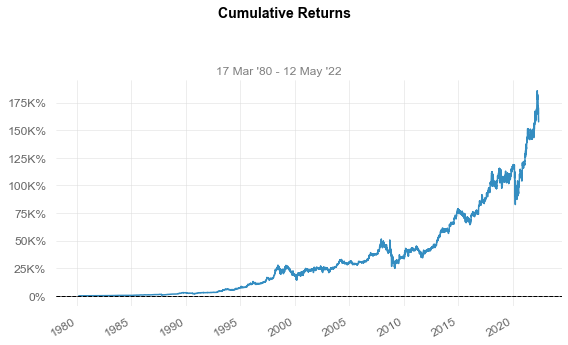

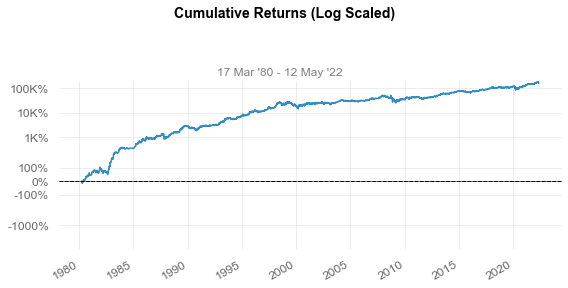

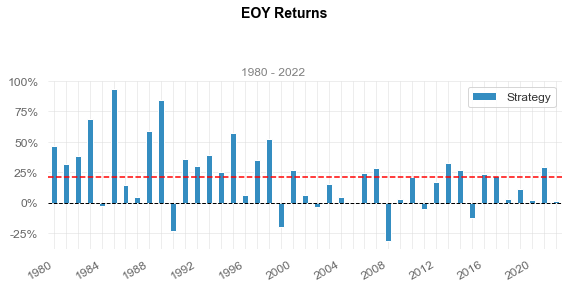

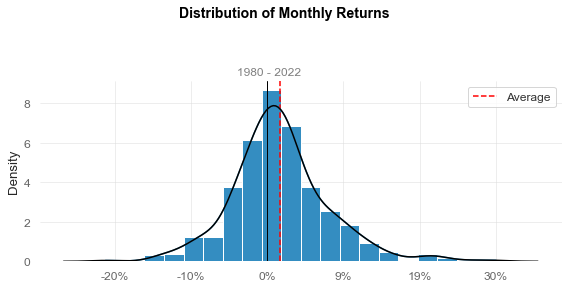

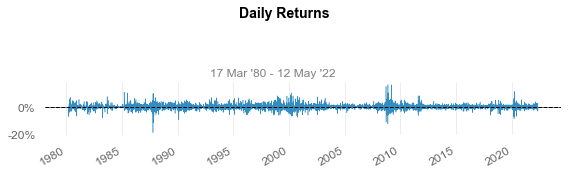

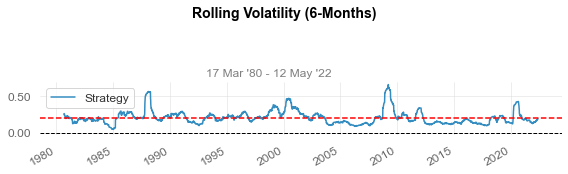

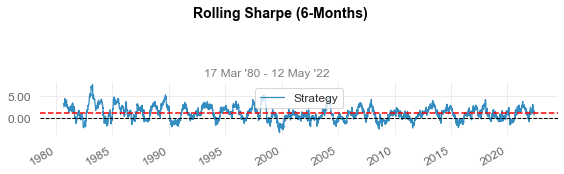

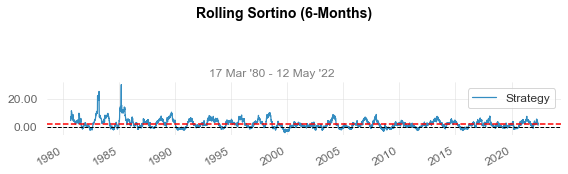

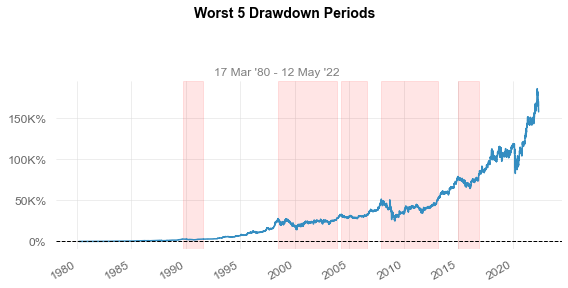

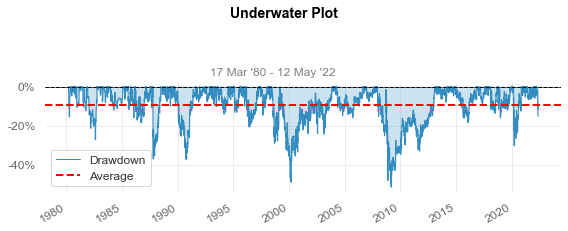

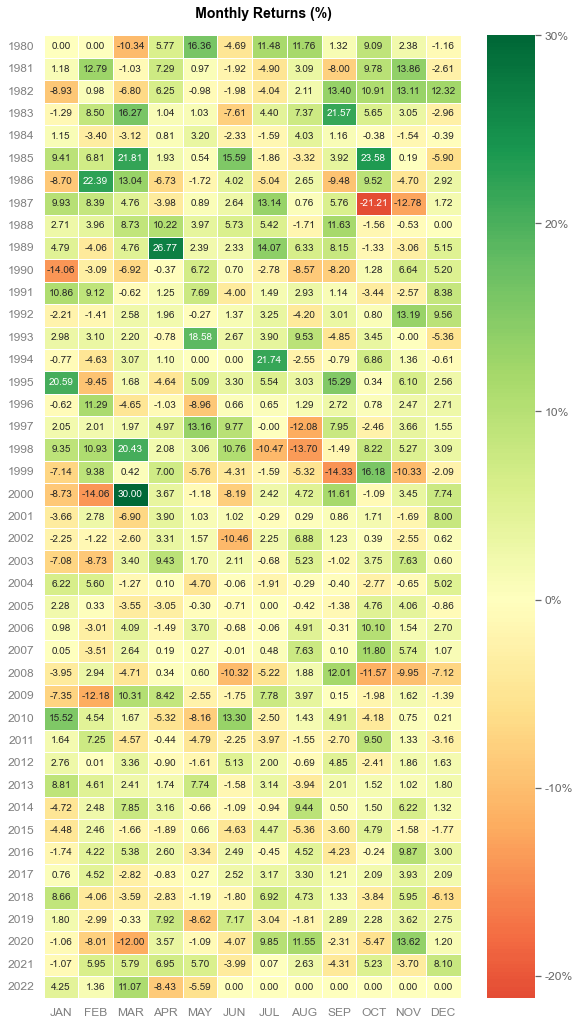

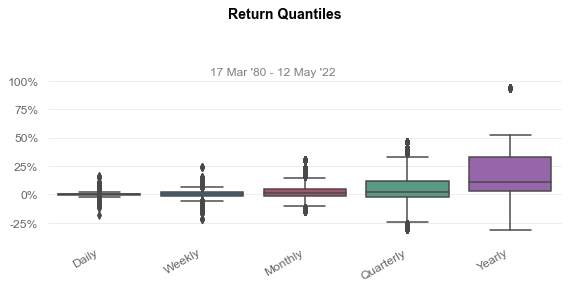

In [8]:
qs.reports.full(returns=stock.squeeze(), rf = 0.02)

In [ ]:
#backtest_report(returns=bench2, out_of_sample_date = '2020-01-01', n_samples = 10000, rf = 0.02)
backtest_report(returns=bench2, eoy = False, rf = 0.02)

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,51.47,2007-12-10,2009-03-05,2013-02-14,1354
1,48.95,1998-06-19,2000-03-10,2003-11-14,1411
2,37.46,1989-10-10,1990-10-11,1991-08-12,480
3,37.06,1987-10-02,1987-10-27,1988-07-11,202
4,30.43,2020-01-17,2020-03-23,2020-11-16,217


/Users/safishajjouz/opt/anaconda3/envs/myport_management_env/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 52.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


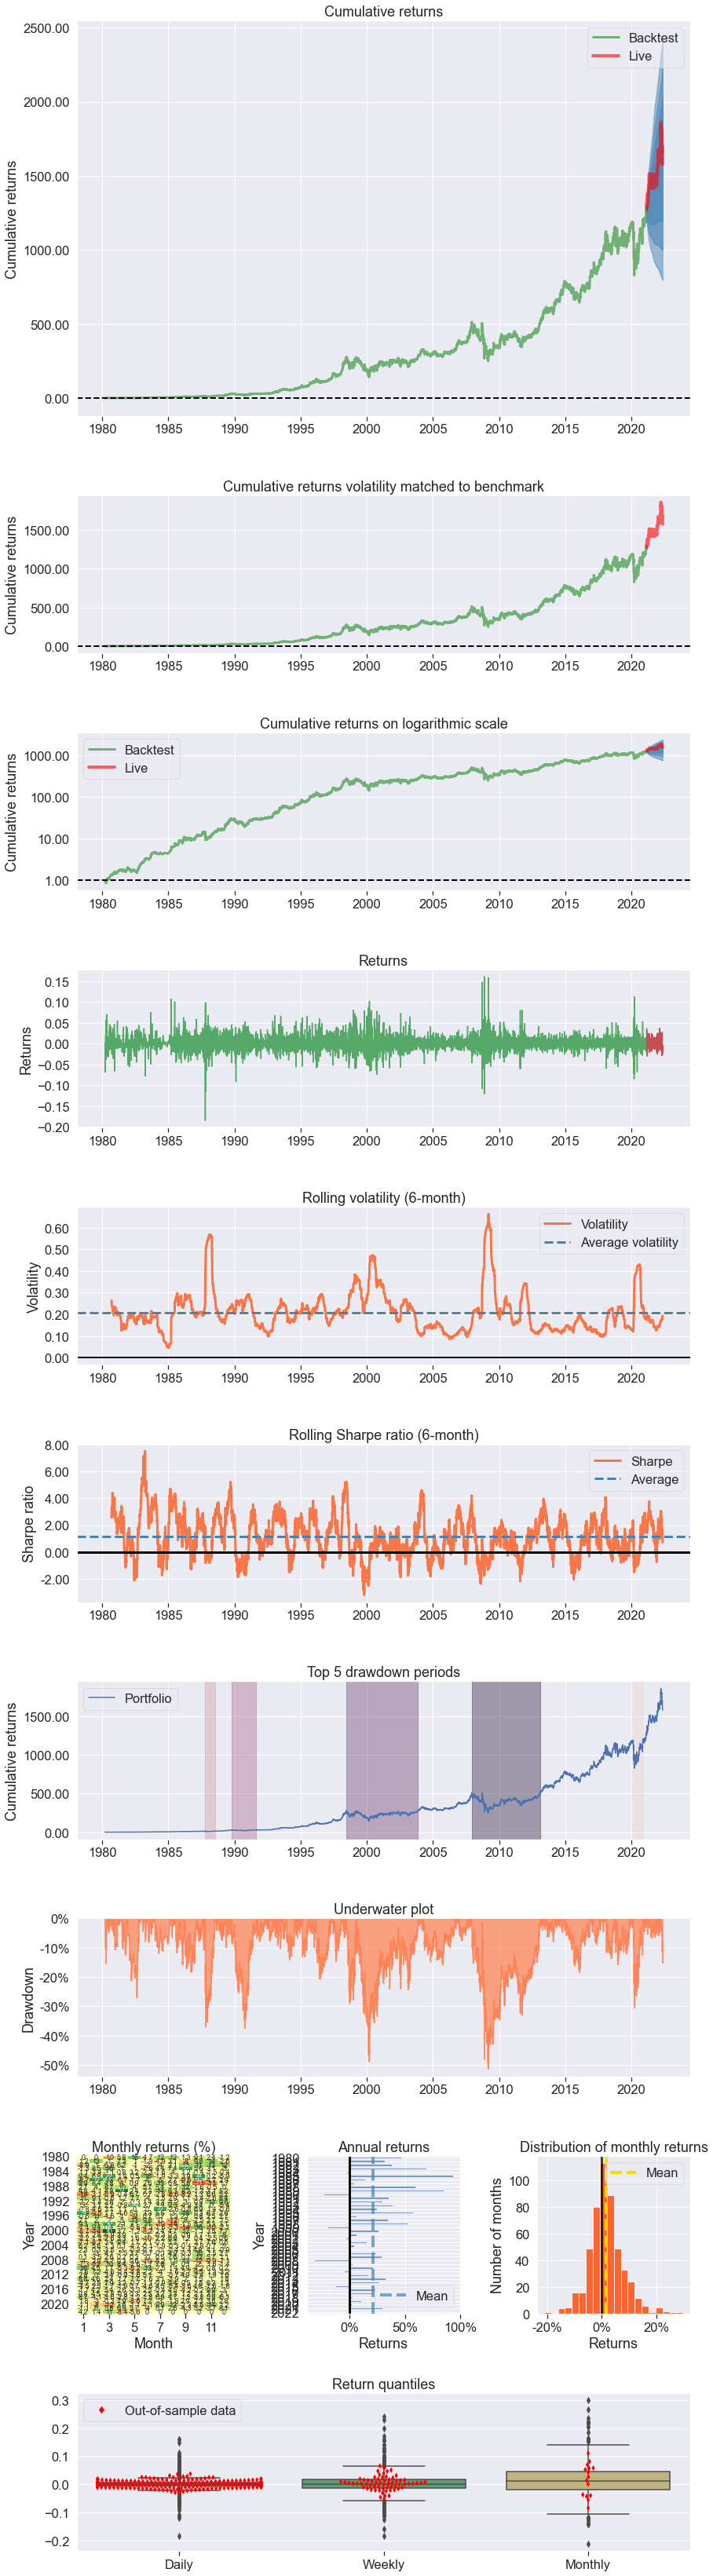

In [9]:
tear_sheet_pyfolio(returns = stock.squeeze(),returns_benchmark=None,
                             live_start_date='2021-03-01',
                             bootstrap= False,                            
                             return_fig=False)

In [ ]:
multi_asset_tickers = ['EEM', 'VNQ', 'MDY', 'SLY', 
                       'SPY', 'EFA', 
                       'TIP', 
                       'AGG', 
                       'DJP', 'BIL']

df_multi_asset = download_returns(multi_asset_tickers)

df_multi_asset = df_multi_asset.dropna()
df_multi_asset = convert_returns_freq(df_multi_asset, convert_to = 'monthly')
fed_rate = download_fred_data(['EFFR'], freq = 'm')


In [ ]:
#portfolio optimisation 
port_series, weights = make_standard_portfolios(df_multi_asset, target_return=0.07, 
                             target_volatility=0.18, 
                             weight_min=0, weight_max = 0.99, 
                             rebalance = None)

port_fed_stress = port_series[(port_series.index>='2015-12-01') & (port_series.index<='2019-04-01')]

df_sp = df_multi_asset[['SPY']]
df_sp = df_sp[(df_sp.index>='2015-12-01') & (df_sp.index<='2019-04-01')]
fed_stress = qs.stats.cagr(port_fed_stress) * 100
df_sp = qs.stats.cagr(df_sp) * 100

fed_stress = pd.concat([fed_stress,df_sp ])

fed_stress.plot.bar('port_naive')


weights[['port_naive']].plot.pie(y = 'port_naive')
